In [1]:
import pandas as pd

In [2]:
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_csv('train.csv')

C:\Users\Kinza\AppData\Local\Temp\ipykernel_1480\3425841524.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

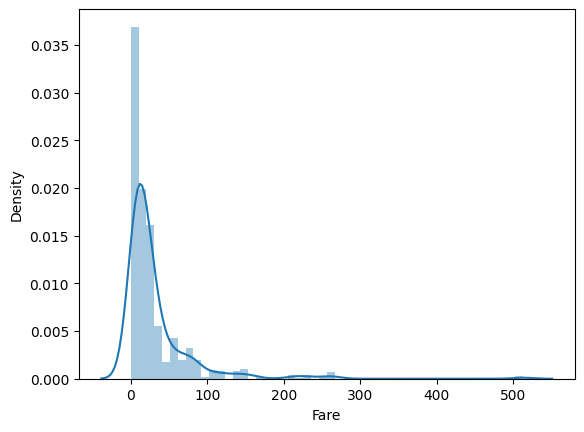

In [7]:
sns.distplot(df['Fare'])

<Axes: ylabel='Fare'>

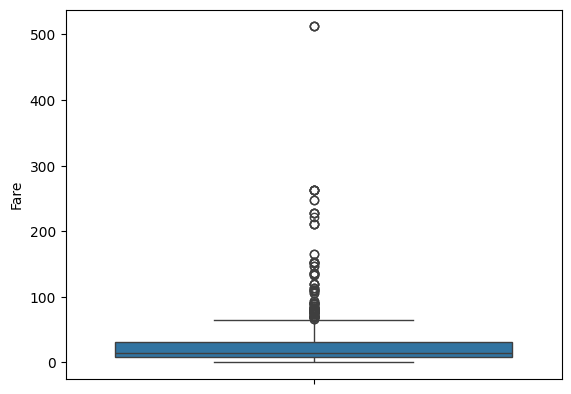

In [8]:
sns.boxplot(df['Fare'])

In [13]:
percentile25=df['Fare'].quantile(0.25)
percentile75=df['Fare'].quantile(0.75)
iqr=percentile75-percentile25
ub=percentile75+1.5*iqr
lb=percentile25-1.5*iqr
print('Upper bound is ',ub)
print('Lower bound is ',lb)

Upper bound is  65.6344
Lower bound is  -26.724


In [18]:
new_df=df[(df['Fare']<ub)&(df['Fare']>lb)]
print("Before Trimming",df.shape)
print("After Trimming",new_df.shape)
new_df['Fare'].describe()

Before Trimming (891, 12)
After Trimming (775, 12)


count    775.000000
mean      17.822091
std       13.578085
min        0.000000
25%        7.895800
50%       13.000000
75%       26.000000
max       65.000000
Name: Fare, dtype: float64

In [22]:
#capping
df['Fare']=np.where(
    df['Fare']>ub,
    ub,
    np.where(
     df['Fare']<lb,
     lb,
     df['Fare']
   )    
)

In [23]:
df['Fare'].describe()

count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: Fare, dtype: float64

In [5]:
ub=df['Fare'].quantile(0.99)
lb=df['Fare'].quantile(0.01)


In [9]:
new_df=df[(df['Fare']<ub)&(df['Fare']>lb)]
print("Before triming",new_df.shape)

Before triming (867, 12)


In [14]:
#capping
new_df=np.where(
    df['Fare']>ub,
    ub,
    np.where(
         df['Fare']<lb,
         lb,
         df['Fare']
     )
)

In [15]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64